In [147]:
from google.colab import files

print("Sube el video .mp4 para procesarlo:")
uploaded = files.upload()

video_path = list(uploaded.keys())[0]
print("Video cargado:", video_path)


Sube el video .mp4 para procesarlo:


Saving sky.mp4 to sky (19).mp4
Video cargado: sky (19).mp4


In [148]:
import cv2
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt


In [149]:
frames = []
frames_cpu = []

cap = cv2.VideoCapture(video_path)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    frames_cpu.append(gray)
    frames.append(cp.asarray(gray))

cap.release()

num_frames = len(frames)
print("Frames cargados:", num_frames)


Frames cargados: 240


In [150]:
stack = cp.stack(frames, axis=0)
background = cp.median(stack, axis=0)


In [151]:
threshold = 60
coords = []

for t in range(num_frames):
    diff = cp.abs(frames[t] - background)
    mask = diff > threshold

    ys, xs = cp.where(mask)

    if len(xs) > 0:
        x_mean = float(cp.mean(xs))
        y_mean = float(cp.mean(ys))
        coords.append([x_mean, y_mean, t])


In [152]:
if len(coords) == 0:
    print("RESULTADO: ❌ No Existe Asteroide")
else:
    print("RESULTADO: ✔️ Existe Asteroide")


RESULTADO: ✔️ Existe Asteroide


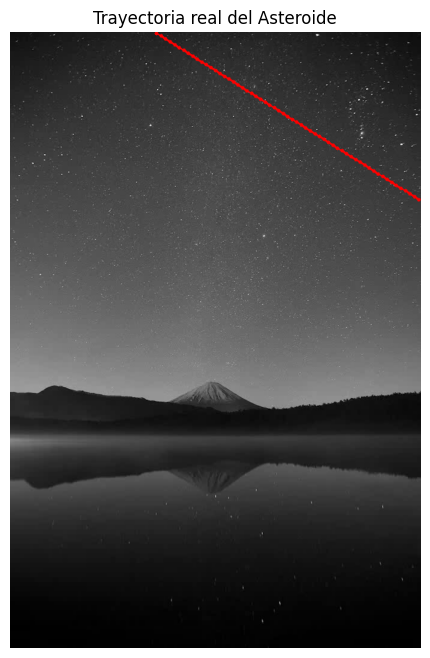

In [153]:
plt.figure(figsize=(8,8))

if len(coords) > 0:
    coords_np = np.array(coords)

    img_final = cv2.cvtColor(frames_cpu[0], cv2.COLOR_GRAY2BGR)

    for i in range(1, len(coords_np)):
        x1, y1 = int(coords_np[i-1][0]), int(coords_np[i-1][1])
        x2, y2 = int(coords_np[i][0]), int(coords_np[i][1])
        cv2.line(img_final, (x1, y1), (x2, y2), (0, 0, 255), 2)

    for x, y, _ in coords_np:
        cv2.circle(img_final, (int(x), int(y)), 3, (0, 0, 255), -1)

    plt.imshow(cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB))
    plt.title("Trayectoria real del Asteroide")
    plt.axis("off")
    plt.show()

else:
    plt.imshow(frames_cpu[0], cmap='gray')
    plt.title("No se detectó asteroide – Fondo Estático")
    plt.axis("off")
    plt.show()
